# Grid Meshes

In [ ]:
import numpy as np
from pprint import pprint
from lucifex.mesh import rectangle_mesh
from lucifex.fem import Function, as_grid_function
from lucifex.viz import plot_colormap, plot_bar
from lucifex.utils.py_utils import log_timing, nested_dict

Nx = 256
Ny = 256
mesh = rectangle_mesh(2.0, 1.0, Ny, Ny)

u = Function((mesh, 'P', 1), lambda x: x[0] * x[1], name='u')
w = Function((mesh, 'P', 1), lambda x: x[0] * x[1] ** 2, name='w')

In [ ]:
f_opts = (u, w)
use_mapping_opts = (True, False)
jit_opts = (True, False)
results_texec = nested_dict((Function, bool, bool, list[float]), depth=3)
results_grid = nested_dict((Function, bool, bool, np.ndarray), depth=3)

for f in f_opts:
    for use_mapping in use_mapping_opts:
        for jit in jit_opts:
            f_grid = log_timing(as_grid_function, results_texec[f.name][use_mapping], jit, n=3)(
                u, jit=jit, use_mapping=use_mapping, use_mesh_cache=False
            )
            results_grid[f.name][use_mapping][jit] = f_grid

pprint(results_texec, sort_dicts=False)

defaultdict(<function nested_dict.<locals>.<lambda> at 0x1040c4820>,
            {'u': defaultdict(<class 'dict'>,
                              {True: {True: [2.911950287001673,
                                             0.5179007539991289,
                                             0.45526413299376145],
                                      False: [0.7521756089990959,
                                              0.757447840005625,
                                              0.7745963439811021]},
                               False: {True: [0.7559761889860965,
                                              0.2645820519537665,
                                              0.25150998402386904],
                                       False: [0.5139346030191518,
                                               0.6181384089868516,
                                               0.5558239969541319]}}),
             'w': defaultdict(<class 'dict'>,
                              {True: {T

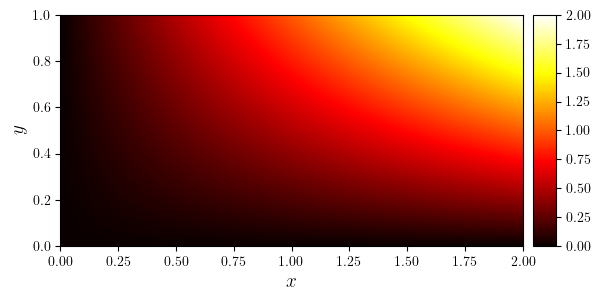

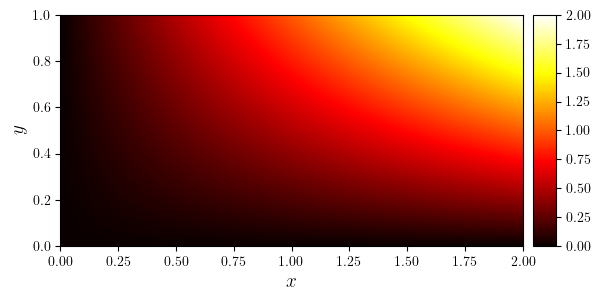

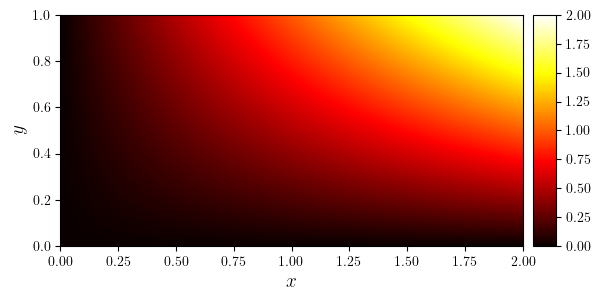

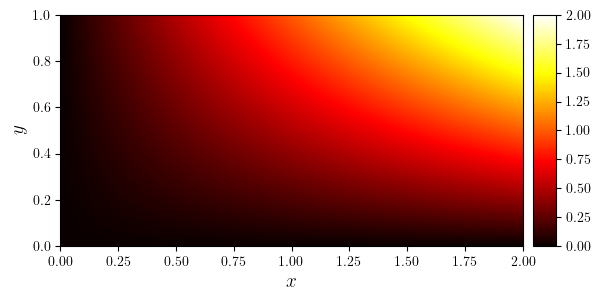

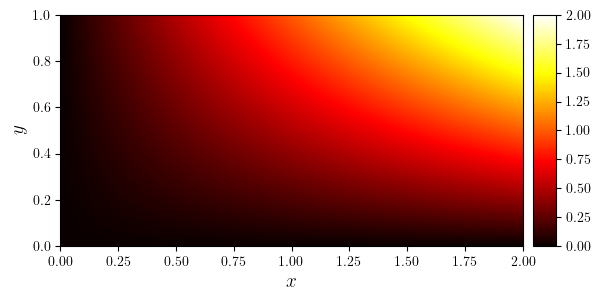

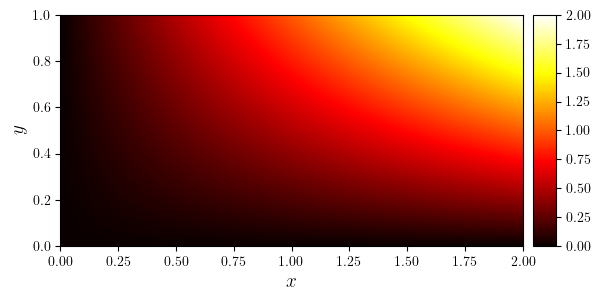

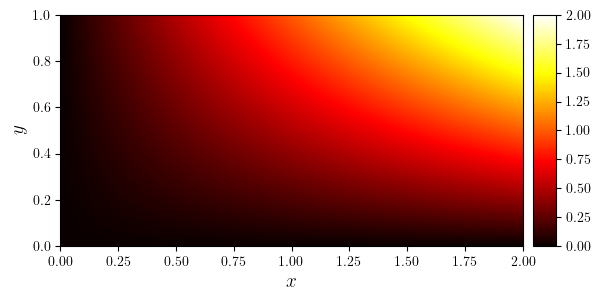

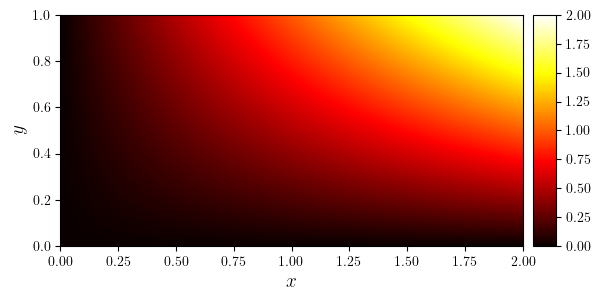

In [ ]:
for f in f_opts:
    for use_mapping in use_mapping_opts:
        for jit in jit_opts:
            f_grid = results_grid[f.name][use_mapping][jit]
            plot_colormap(f_grid)